## 資料的初步探索

<font color=skyblue>以城市生活品質資料分析為例</font>

本筆記本針對 `data/city_quality.xlsx` 資料集進行探索與分析，內容包含：

1. **讀取資料**：讀取城市生活品質資料並檢視前幾筆資料。
2. **原始資料分布**：以箱型圖（boxplot）檢視各變數的分布情形。
3. **資料標準化與比較**：對數值變數進行標準化（z-score），並將原始資料與標準化後資料的箱型圖並排比較。
4. **相關係數矩陣**：計算各變數間的相關係數，並以熱力圖（heatmap）呈現。
5. **主成分分析（PCA）**：對標準化後的資料執行 PCA，並繪製陡坡圖（scree plot）與柏拉圖（Pareto plot），觀察各主成分的解釋變異量與累積解釋變異量。


<font color="yellow">讀取檔案並呈現部分資料以供觀察</font>

** 表格的呈現方式：以 pandas 為例。

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("data/city_quality.xlsx")
# print(df.head())
# df = df.dropna(subset=["City", "Quality of Life Index"])
df.head()

,climate,housing,health,crime,transportation,education,arts,recreation,economics
0,521,6200,237,923,4031,2757,996,1405,7633
1,575,8138,1656,886,4883,2438,5564,2632,4350
2,468,7339,618,970,2531,2560,237,859,5250
3,476,7908,1431,610,6883,3399,4655,1617,5864
4,659,8393,1853,1483,6558,3026,4496,2612,5727


<font color="yellow">繪製箱型圖（boxplot）以檢視各變數的分布情形，並加上網格線以便觀察。</font>

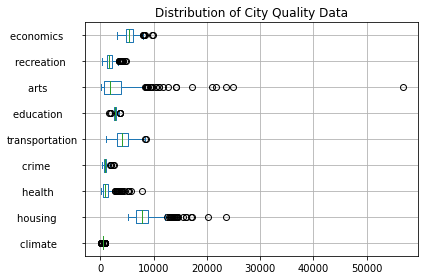

In [3]:
df.plot(kind="box", figsize=(6, 4), vert=False)
plt.title("Distribution of City Quality Data")
plt.tight_layout()
# add grid lines to the boxplot
plt.grid(True)
plt.show()

<font color="yellow">對數值變數進行標準化（z-score），並比較原始資料與標準化後資料的箱型圖，觀察標準化對資料分布的影響。</font>

- 標準化的方式選擇很多，譬如使用 sklearn 套件的 StandardScaler()
- boxplot 的呈現方式非常豐富，試試其他的。

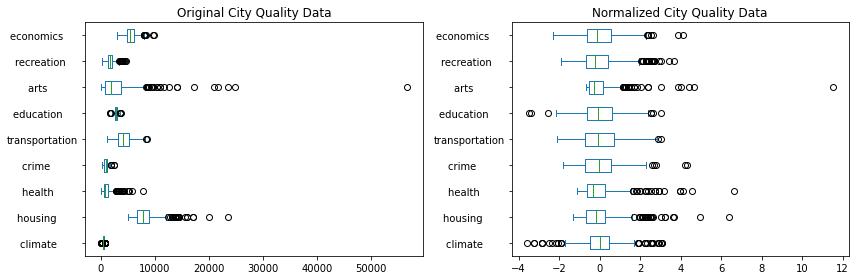

In [4]:
numeric_df = df.select_dtypes(include="number")
normalized_df = (numeric_df - numeric_df.mean()) / numeric_df.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
numeric_df.plot(kind="box", vert=False, ax=axes[0])
axes[0].set_title("Original City Quality Data")
normalized_df.plot(kind="box", vert=False, ax=axes[1])
axes[1].set_title("Normalized City Quality Data")
plt.tight_layout()
plt.show()

<font color="yellow">計算各變數間的相關係數，並以熱力圖（heatmap）呈現</font>

- 這是「純手工」打造的熱力圖
- 試試 seaborn 套件的熱力圖 seaborn.heatmap()


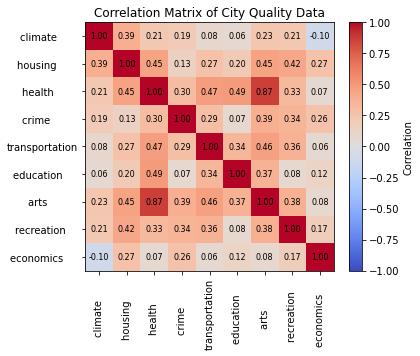

In [5]:
import numpy as np

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of City Quality Data")
plt.tight_layout()
plt.show()

<font color="yellow">觀察資料矩陣的結構與分布情形，並進行主成分分析（PCA）以降低資料維度。</font>

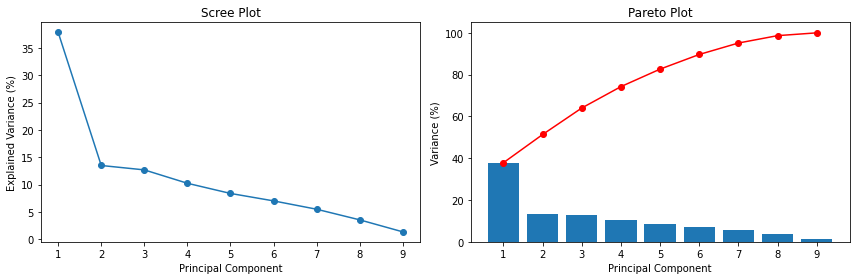

In [6]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(normalized_df)
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
components = range(1, len(explained_var) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(components, explained_var, marker="o")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(components)

axes[1].bar(components, explained_var)
axes[1].plot(components, cumulative_var, color="red", marker="o")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Variance (%)")
axes[1].set_title("Pareto Plot")
axes[1].set_xticks(components)

plt.tight_layout()
plt.show()

<font color="yellow">繪製前兩個主成分的散佈圖，觀察資料在主成分空間的分布情形。</font>
下面的程式碼由 inline code 生成，不影響 AI Usage 的 credits。

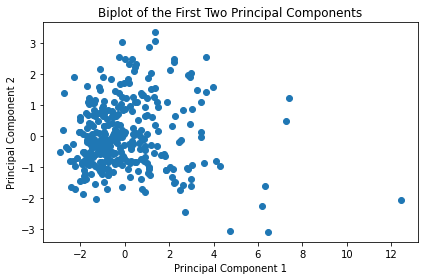

In [7]:
# draw a biplot of the first two principal components
pca_2d = PCA(n_components=2)
pca_2d.fit(normalized_df)
transformed_df = pca_2d.transform(normalized_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(transformed_df[:, 0], transformed_df[:, 1])
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Biplot of the First Two Principal Components")
plt.tight_layout()
plt.show()


<font color=yellow>呈現主成分與原始變數的組合關係</font>

- 主成分（$Z_i$）是原始變數（$X_i$）的重組，其變異數（"能量"）遞減。 
$$Z_1 = a_{11}X_1 + a_{12}X_2 + \cdots + a_{19}X_9$$
$$Z_2 = a_{21}X_1 + a_{22}X_2 + \cdots + a_{29}X_9$$
- 組合係數（$a_{ij}$）大小代表該原始變數（$X_j$）的特徵參與度。

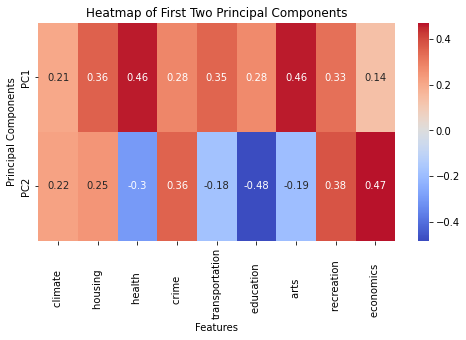

In [10]:
# draw the heatmap of the first two principal components
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
# add xticklabels and yticklabels to the heatmap
feature_names = normalized_df.columns
sns.heatmap(pca.components_[:2], annot=True, cmap='coolwarm', center=0, xticklabels=feature_names, yticklabels=['PC1', 'PC2'])
plt.title('Heatmap of First Two Principal Components')
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.show()